In [7]:
# Моделирование розыгрыша и вылета частицы из реактора с помощью методов Монте-Карло.

In [8]:
# Шар радиусом R=1 см заполнен искусственными элементами - чистым поглотителем Σa=0.5  и чистым рассеивателем Σs=0.5 
# и помещен в вакуум. Плотность вещества шара ρ=1.  Центр шара совпадает с центром системы координат.
# В центре системы в точке (0; 0; 0) расположен мгновенный изотропный источник нейтронов.
# 1)	Рассчитать вероятность выхода нейтрона из системы;
# 2)	Построить зависимость вероятности выхода нейтронов из системы от радиуса ;
# 3)	Построить зависимость вероятности выхода нейтронов из системы от сечения поглощения Σa;
# 4)	Оценить стандартную ошибку численного решения;
# 5)	Сравнить полученные результаты с эталонными результатами, полученными по программе ПРИЗМА [1,2].


In [9]:
# Алгоритм моделирования переноса частиц 
# Для  каждого столкновения нейтрона с атомами вещества системы возможны лишь два исхода: 
# рассеяние и захват. В рамках рассмотренного приближения, сечения реакций не зависят от энергии. 
# Направления при моделировании эквиваленты в силу чистоты поглотителя и рассеивателя. Из-за вакуума возврата частиц нет.


In [10]:
# Алгоритм: 
# 1.	Задание начальных данных: сечений, радиуса, числа моделируемых частиц, начальных координат и направления движения частицы;
# 2.	Поиск расстояния до границы области;
# 3.	Розыгрыш свободного пробега;
# 4.	Перенос частицы: если за границу области – переход к пункту 1;
# если частица внутри области – переход к пункту 5;
# 5.	Розыгрыш соударения:
# - в случае поглощения – переходим к пункту 1;
# - в случае рассеяния – розыгрыш направления, переход к пункту 2.


In [11]:
# Подключаем необходимые библиотеки
import numpy as np # Библиотека для работы с математическими вычислениями
import random 
import matplotlib # Библеотека для построения графиков
import matplotlib.pyplot as plt

# Начальные данные
R = 1       # радиус шарика
p_a = 0.5 # вероятность поглощения
p_s = 0.5 # вероятность рассеяния

# Процедура для розыгрыша пробега
def get_path(p_a,p_s):
    gamma_1 = random.random() #генерируем случайное число  
    gamma_2 = random.random()#генерируем случайное число 
   #применяем формулу метода обратной функции для нахождения длины пробега
    l_a = - 1/p_a * np.log(gamma_1)
    l_s = - 1/p_s * np.log(gamma_2)
    #выбираем наименьший из пробегов
    if l_a > l_s :
        return(l_s, 'sct' )
    else :
        return(l_a, 'abs')

# Процедура 'розыгрыша' начальных параметров частицы
def source():
    x = np.zeros(3) # задаем появление нейтрона в начале координат (0,0,0)
    w = np.array([0,0,1]) # задаем направляющий единичный вектор
                                      #(можем так поступить в силу того что источник изотропный)
    return x, w

# История частицы
def history(p_a,p_s,R):
    x, w = source() # рождение частицы
    live = True       # задаем признак жизни
    
    while live: # пока частица жива
        l_path, life = get_path(p_a, p_s)    # получаем длину пути и состояние частицы
        x_1 = x[0] + l_path * w[0] # смещение по координате x
        x_2 = x[1] + l_path * w[1] # смещение по координате y
        x_3 = x[2] + l_path * w[2] # смещение по координате z
        x = np.array([x_1,x_2,x_3]) 
        #смотрим на расстояние между новой координатой и началом координат
        distance = np.sqrt( x[0]**2 + x[1]**2 + x[2]**2 )
        if distance > R: # если расстояние больше заданного радиуса сферы
            live = False # история частицы прекращается
            return 'escape' # вернем «вылет»
        elif  life == 'abs': # смотрим поглощена ли частица
            live = False # частица поглощена 
            return 'absorbtion'# вернем «поглощение»
        else: # частица рассеялась 
        # задаем новое направление
            w_1, w_2, w_3 = 1, 1, 1
            while ((w_1**2+w_2**2+w_3**2)>1):
                w_1 = 2*random.random()-1 #
                w_2 = 2*random.random()-1 #
                w_3 = 2*random.random()-1 #
            s = np.sqrt(w_1**2+w_2**2+w_3**2)
            a = w_1/s
            b = w_2/s
            c = w_3/s
            w = np.array([a,b,c]) #задали новое направление
       #возвращаемся в начало цикла и проделываем все еще раз, пока частица не закончит свою историю

# Процедура поиска вероятности
def flag(n_hist):
    counter = 0
    for hist in range(n_hist):
        event = history(p_a,p_s,R)
        if event == 'escape':
            counter += 1    
    esc_prob = counter / n_hist # считаем вероятность вылета 
    return esc_prob # выводим вероятность

print(flag(1000000))#поиск вероятности вылета для  миллиона частиц



0.561343


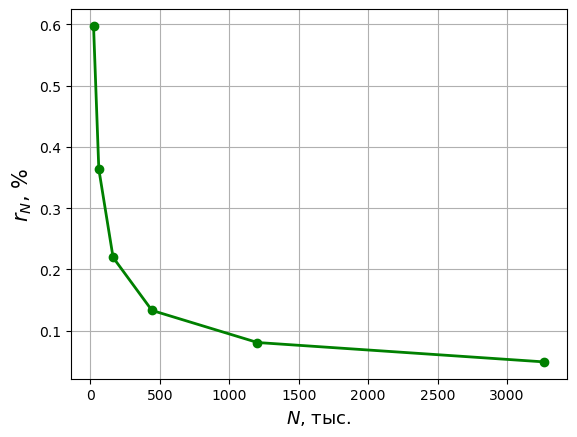

In [ ]:
# Приложения
# 1.Построение графика зависимости ошибки от числа историй
#Подключение необходимых библеотек
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt

# Начальные данные
R = 1       # радиус шарика
p_a = 0.5 # вероятность поглощения
p_s = 0.5 # вероятность рассеяния

# Процедура для розыгрыша пробега
def get_path(p_a,p_s):
    gamma_1 = random.random() #генерируем случайное число  
    gamma_2 = random.random()#генерируем случайное число 
   #применяем формулу метода обратной функции для нахождения длины пробега
    l_a = - 1/p_a * np.log(gamma_1)
    l_s = - 1/p_s * np.log(gamma_2)
    #выбираем наименьший из пробегов
    if l_a > l_s :
        return(l_s, 'sct' )
    else :
        return(l_a, 'abs')

# Процедура 'розыгрыша' начальных параметров частицы
def source():
    x = np.zeros(3) # задаем появление нейтрона в начале координат (0,0,0)
    w = np.array([0,0,1]) # задаем направляющий единичный вектор
                                      #(можем так поступить в силу того что источник изотропный)
    return x, w

# История частицы
def history(p_a,p_s,R):
    x, w = source() # появление частицы
    live = True          
    while live: # пока частица жива
        l_path, life = get_path(p_a, p_s)    # получаем длину пути и состояние частицы
        x_1 = x[0] + l_path * w[0] # смещение по координате x
        x_2 = x[1] + l_path * w[1] # смещение по координате y
        x_3 = x[2] + l_path * w[2] # смещение по координате z
        x = np.array([x_1,x_2,x_3]) 
        #смотрим на расстояние между новой координатой и началом координат
        distance = np.sqrt( x[0]**2 + x[1]**2 + x[2]**2 )
        if distance > R: # если расстояние больше заданного радиуса сферы
            live = False # история частицы прекращается
            return 'escape' # вернем «вылет»
        elif  life == 'abs': # смотрим поглощена ли частица
            live = False # частица поглощена 
            return 'absorbtion'# вернем «поглощение»
        else: # частица рассеялась 
        # задаем новое направление
            w_1, w_2, w_3 = 1, 1, 1
            while ((w_1**2+w_2**2+w_3**2)>1):
                w_1 = 2*random.random()-1 #
                w_2 = 2*random.random()-1 #
                w_3 = 2*random.random()-1 #
            s = np.sqrt(w_1**2+w_2**2+w_3**2)
            a = w_1/s
            b = w_2/s
            c = w_3/s
            w = np.array([a,b,c]) #задали новое направление
       #возвращаемся в начало цикла и проделываем все еще раз, пока частица не закончит свою историю

# Процедура нахождения дисперсии
def disp(n_hist):
    counter = 0
    for hist in range(n_hist):
        event = history(p_a,p_s,R)
        if event == 'escape':
            counter += 1    
    disp = (counter-(pow(counter, 2)/(n_hist)))/(n_hist-1)     
    esc_prob = counter / n_hist # считаем вероятность вылета 
    return esc_prob, disp, counter # выводим вероятность, дисперсию и количество вылетевших частиц

# Процедура подсчета пары вероятности и ошибки 
def mistake(n_hist):
    n = 10        
    for i in range(n): 
        p, disper, counter  = disp(n_hist)    
        sigma = (np.sqrt(disper*n_hist))/counter
        return(sigma*100)
    
SGM = [] # создаем список ошибок
COUNT_HIST = [] # создаем список числа историй   

for i in np.arange(10, 16, 1):
# берем целые степени экспоненты для нахождения «оптимального» числа частиц
    tmp = int(np.exp(i)) 
    sgm = mistake(tmp)

    SGM.append(sgm) # добавляем ошибку в список 
#добавляем число историй в список и делим на 1000 для «красоты» на графике
    COUNT_HIST.append(tmp/1000)

#Строим график
fig, ax = plt.subplots()   
ax.plot(COUNT_HIST,SGM, '-o' , color = 'green', linewidth = 2)
ax.set_xlabel('$N$, тыс.', fontsize = 13)
ax.set_ylabel('$r_N$, %', fontsize = 15)
plt.grid()
plt.show()

# 2.Построение графика зависимости вероятности вылета нейтрона из системы от радиуса. Сравнение результатов с данными полученными программой ПРИЗМА.

import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt

# Начальные данные 
p_a = 0.5 # вероятность поглощения
p_s = 0.5 # вероятность рассеяния

# Процедура для розыгрыша пробега
def get_path(p_a,p_s):
    gamma_1 = random.random() #генерируем случайное число  
    gamma_2 = random.random()#генерируем случайное число 
   #применяем формулу метода обратной функции для нахождения длины пробега
    l_a = - 1/p_a * np.log(gamma_1)
    l_s = - 1/p_s * np.log(gamma_2)
    #выбираем наименьший из пробегов
    if l_a > l_s :
        return(l_s, 'sct' )
    else :
        return(l_a, 'abs')

# Процедура 'розыгрыша' начальных параметров частицы
def source():
    x = np.zeros(3) # задаем появление нейтрона в начале координат (0,0,0)
    w = np.array([0,0,1]) # задаем направляющий единичный вектор
                                      #(можем так поступить в силу того что источник изотропный)
    return x, w

# История частицы
def history(p_a,p_s,R):
    x, w = source() # рождение частицы
    live = True       # задаем признак жизни
    
    while live: # пока частица жива
        l_path, life = get_path(p_a, p_s)    # получаем длину пути и состояние частицы
        x_1 = x[0] + l_path * w[0] # смещение по координате x
        x_2 = x[1] + l_path * w[1] # смещение по координате y
        x_3 = x[2] + l_path * w[2] # смещение по координате z
        x = np.array([x_1,x_2,x_3]) 
        #смотрим на расстояние между новой координатой и началом координат
        distance = np.sqrt( x[0]**2 + x[1]**2 + x[2]**2 )
        if distance > R: # если расстояние больше заданного радиуса сферы
            live = False # история частицы прекращается
            return 'escape' # вернем «вылет»
        elif  life == 'abs': # смотрим поглощена ли частица
            live = False # частица поглощена 
            return 'absorbtion'# вернем «поглощение»
        else: # частица рассеялась 
        # задаем новое направление
            w_1, w_2, w_3 = 1, 1, 1
            while ((w_1**2+w_2**2+w_3**2)>1):
                w_1 = 2*random.random()-1 #
                w_2 = 2*random.random()-1 #
                w_3 = 2*random.random()-1 #
            s = np.sqrt(w_1**2+w_2**2+w_3**2)
            a = w_1/s
            b = w_2/s
            c = w_3/s
            w = np.array([a,b,c]) #задали новое направление
       #возвращаемся в начало цикла и проделываем все еще раз, пока частица не закончит свою историю
       
  
# Процедура поиска дисперсии
def flag(R): # подаем на вход функции значение радиуса
    n_hist = 1000000 # берем историй по 
    counter = 0
    for hist in range(n_hist):
        event = history(p_a,p_s,R) # передаем в функцию значения сечений и выбранный нами радиус
        if event == 'escape':
            counter += 1    
    disp = (counter-(pow(counter, 2)/(n_hist)))/(n_hist-1)     
    esc_prob = counter / n_hist # считаем вероятность вылета 
    return esc_prob, disp, counter # выводим вероятность, дисперсию и число вылетевших частиц 

# Процедура подсчета пары вероятности и ошибки 
def mistake(R):
    n_hist = 1000000 # берем историй по 
    n = 10 # 10 раз прогоняем  историй частиц      
    for i in range(n): 
        p, disper, counter  = flag(R) # получаем вероятность, дисперсию и количество вылетевших частиц 
        sigma = (np.sqrt(disper*n_hist))/counter # считаем ошибку
        return(p, sigma) # возращаем вероятность и ошибку

#Процедура создания списков радиусов, ошибок и доверительного интервала
def graf(): 
    P = []
    Rad = []
    interval_1 = [] 
    interval_2 = []
    Rad1 = []
    Rad2 = []
    for R in np.arange(0.5, 4.25,0.25):        
        p, miss = mistake(R)
        
        if (p >= 0) and (p <= 1):
            Rad.append(R)     
            P.append(p)
        k = 0    
        if(p-miss):
            k = p-miss
            interval_1.append(k)
            Rad1.append(R)
        if(p+miss):
            k = p+miss
            interval_2.append(k)  
            Rad2.append(R)
        
    return(P, Rad , interval_1, interval_2, Rad1, Rad2)

P, Rad, interval_1, interval_2, Rad1, Rad2 = graf()   

#Воспроизведение данных полученных из программы ПРИЗМА
prisma_R = Rad
prisma_P = np.array([0.7624 , 0.6564, 0.5608, 0.4758, 0.4014, 0.3369, 0.2815, 0.2343, 0.1944, 0.1608, 0.1326, 0.1091, 0.08962, 0.07345, 0.06009])

#Создаем график
fig, ax = plt.subplots()   
ax.plot( Rad, P, '-o' , color = 'green', linewidth = 2, label = 'Численное решение')
ax.plot( Rad1, interval_1, '--' , color = 'red', linewidth = 1, label = 'Численное решение $\pm\sigma$')
ax.plot( Rad2, interval_2, '--' , color = 'red', linewidth = 1)
ax.plot( prisma_R, prisma_P,'x' , color = 'black' , linewidth = 1, label = 'Результаты программы ПРИЗМА')
ax.legend(loc = 'best')
ax.set_xlabel('R, см', fontsize = 15)
ax.set_ylabel('p', fontsize = 15)

plt.ylim([0.65, 0.675]) # масштабирование по оси 
plt.xlim([0.725, 0.775]) # масштабирование по оси  

# 3.Построение графика зависимости вероятности вылета нейтрона из системы от сечения поглощения.
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt

# Начальные данные
R = 1       # радиус шарика

# Процедура для розыгрыша пробега
def get_path(p_a,p_s):
    gamma_1 = random.random() #генерируем случайное число  
    gamma_2 = random.random()#генерируем случайное число 
   #применяем формулу метода обратной функции для нахождения длины пробега
    l_a = - 1/p_a * np.log(gamma_1)
    l_s = - 1/p_s * np.log(gamma_2)
    #выбираем наименьший из пробегов
    if l_a > l_s :
        return(l_s, 'sct' )
    else :
        return(l_a, 'abs')

# Процедура 'розыгрыша' начальных параметров частицы
def source():
    x = np.zeros(3) # задаем появление нейтрона в начале координат (0,0,0)
    w = np.array([0,0,1]) # задаем направляющий единичный вектор
                                      #(можем так поступить в силу того что источник изотропный)
    return x, w

# История частицы
def history(p_a,p_s,R):
    x, w = source() # рождение частицы
    live = True       # задаем признак жизни
    
    while live: # пока частица жива
        l_path, life = get_path(p_a, p_s)    # получаем длину пути и состояние частицы
        x_1 = x[0] + l_path * w[0] # смещение по координате x
        x_2 = x[1] + l_path * w[1] # смещение по координате y
        x_3 = x[2] + l_path * w[2] # смещение по координате z
        x = np.array([x_1,x_2,x_3]) 
        #смотрим на расстояние между новой координатой и началом координат
        distance = np.sqrt( x[0]**2 + x[1]**2 + x[2]**2 )
        if distance > R: # если расстояние больше заданного радиуса сферы
            live = False # история частицы прекращается
            return 'escape' # вернем «вылет»
        elif  life == 'abs': # смотрим поглощена ли частица
            live = False # частица поглощена 
            return 'absorbtion'# вернем «поглощение»
        else: # частица рассеялась 
        # задаем новое направление
            w_1, w_2, w_3 = 1, 1, 1
            while ((w_1**2+w_2**2+w_3**2)>1):
                w_1 = 2*random.random()-1 #
                w_2 = 2*random.random()-1 #
                w_3 = 2*random.random()-1 #
            s = np.sqrt(w_1**2+w_2**2+w_3**2)
            a = w_1/s
            b = w_2/s
            c = w_3/s
            w = np.array([a,b,c]) #задали новое направление
       #возвращаемся в начало цикла и проделываем все еще раз, пока частица не закончит свою историю

# Процедура создания списков вероятностей и вероятностей сечения поглощения
def graf():
    P = []
    A =[]
    for p_a in np.arange(0.5, 0.91, 0.05): # задаем интервал создания числа вероятности и шаг
        p_s = 1-p_a # находим сечение рассеяния       
        p = flag(p_a,p_s) # находим вероятность для полученных сечений
        A.append(p_a)     
        P.append(p)
# возвращаем список вероятностей вылета и вероятностей сечения поглощения
    return(P, A) 

P, A = graf()   

prisma_p_a = A
prisma_P = np.array([0.561, 0.5348, 0.5107, 0.4882, 0.4673, 0.4478, 0.4297, 0.4127, 0.3968])

# Создаем график
fig, ax = plt.subplots()   
ax.plot(A, P, '-o' , color = 'green', linewidth = 2, label = 'Численное решение')
ax.plot( prisma_p_a, prisma_P,'x' , color = 'black' , linewidth = 1, label = 'Результаты программы ПРИЗМА')

ax.set_ylabel('p', fontsize = 15)
ax.set_xlabel('$\sum a$', fontsize = 15)
ax.legend(loc = 'best')

plt.ylim([0.445, 0.450]) # масштабирование по оси  
plt.xlim([0.725, 0.775]) # масштабирование по оси  

plt.grid() # создаем «сеточку»
plt.show() # команда «показать график»



In [ ]:
# Заключение
#  В рамках практики были изучены основные понятия теории переноса и метода Монте-Карло: уравнение переноса, метод обратной функции, алгоритмы моделирования пробега и вектора направления полета частицы. Полученные знания были использованы для решения поставленной задачи – переноса нейтронов в шаре. 
#  Для решения задачи на языке Python была написана программа, которая позволяет определить вероятность вылета частицы из системы. Была получена зависимость ошибки численного решения от числа испытаний и показана обратная зависимость вероятности вылета частицы из шара от радиуса шара и сечения поглощения.
#  Показано хорошее согласие результатов реализованной программы с эталонными результатами, полученными по программе ПРИЗМА.
